# Prophet Training (2016–2019) - Respira SP

Este notebook implementa e avalia o modelo **Prophet** para previsão de `PM2.5` 24 horas à frente,
utilizando a base histórica de **2016–2019** da Estação 08 — Congonhas (CETESB).

Foram comparadas três estratégias de pré-processamento para tratamento de gaps,
além de diferentes configurações do Prophet: modelo baseline (apenas sazonalidades),
modelo com regressores meteorológicos, modelo com sazonalidade multiplicativa,
modelo com indicador de inverno (`is_winter`) e modelo com hiperparâmetros otimizados via Grid Search.

---

## O que foi feito

* Carregamento das três bases de dados referentes às estratégias de pré-processamento;
* Preparação dos dados no formato exigido pelo Prophet:
  * Renomeação de `time` → `ds` e `MP2.5` → `y`;
  * Remoção do timezone UTC da coluna `ds`;
* Criação do indicador de inverno `is_winter` (junho, julho e agosto = 1);
* Realização do split temporal dos dados:
  * Treino: dados anteriores a 2018;
  * Validação: dados de 2018;
  * Teste: dados de 2019;
* Visualização da divisão temporal da série de PM2.5;
* Treinamento do **Prophet Baseline** (sem regressores externos) para as três estratégias;
* Treinamento do **Prophet com regressores meteorológicos** (`temperature_2m`, `relative_humidity_2m`, `precipitation`, `wind_speed_10m`);
* Avaliação dos modelos com `MAE`, `RMSE` e `R²` em validação e teste;
* Teste do modo de sazonalidade **multiplicativo** como alternativa ao aditivo;
* Teste do regressor `is_winter` para capturar o período crítico de inverno;
* Análise comparativa de todos os experimentos na validação;
* Realização de **Grid Search manual** sobre os hiperparâmetros:
  * `changepoint_prior_scale`: [0.001, 0.01, 0.1, 0.5]
  * `seasonality_prior_scale`: [0.01, 0.1, 1.0, 10.0]
* Treinamento do **Prophet Tuned** com os melhores hiperparâmetros encontrados;
* Avaliação do modelo tuned em validação e teste;
* Análise dos **componentes do Prophet** (tendência, sazonalidade semanal, anual e diária);
* Realização de **cross-validation walk-forward nativo do Prophet** com `initial="500 days"`, `period="30 days"` e `horizon="24 hours"`;
* Análise do erro (`MAE` e `RMSE`) por horizonte de previsão (1h a 24h à frente).

---

## Melhor configuração encontrada

**Base:** 2016–2019
**Estratégia:** Estratégia 1 — sem interpolação (NaNs preservados)
**Modelo:** Prophet Tuned — `changepoint_prior_scale=0.001`, `seasonality_prior_scale=0.01`
**Regressores:** `temperature_2m`, `relative_humidity_2m`, `precipitation`, `wind_speed_10m`

### Resultado em validação

* `MAE`: 8.527
* `RMSE`: 11.815
* `R²`: 0.184

### Resultado em teste

* `MAE`: 8.673
* `RMSE`: 11.835
* `R²`: 0.172

---

## Observações

O Prophet demonstrou capacidade de capturar os padrões sazonais da série de PM2.5 —
sazonalidade diária com picos na madrugada e fim de tarde, sazonalidade semanal com
vale na segunda-feira e pico na quinta/sexta, e sazonalidade anual com período crítico
entre julho e setembro, consistente com o inverno seco de São Paulo.

Entretanto, o modelo apresenta limitação estrutural na captura de picos extremos de PM2.5,
que são causados por eventos episódicos (inversão térmica, condições meteorológicas atípicas)
não representáveis pela decomposição aditiva do Prophet.

O modo de sazonalidade **multiplicativo** foi testado e descartado — o comportamento da série
de PM2.5, com valores frequentemente próximos de zero, é incompatível com esse modo e
resultou em degradação severa das métricas (MAE ~17, R² ~ -1.9).

O indicador `is_winter` não trouxe melhora para a Estratégia 1, provavelmente porque o
Prophet já captura o período crítico via sazonalidade anual e os NaNs preservados nessa
estratégia representam melhor a variabilidade real da série.

A **Estratégia 1 foi a melhor para o Prophet** — diferente do XGBoost e LightGBM, onde
estratégias com imputação performaram melhor. Isso ocorre porque o Prophet lida nativamente
com dados faltantes no treino, enquanto a imputação artificial introduz padrões que não
se generalizam para o período de teste.

O Grid Search identificou `changepoint_prior_scale=0.001` como valor ideal — tendência
muito rígida, próxima de linear — coerente com a natureza da série de PM2.5, que não
apresenta tendência de crescimento ou queda pronunciada no período analisado.

A análise por horizonte de previsão revelou que o erro não cresce monotonicamente,
mas oscila conforme a sazonalidade diária: menores erros entre 5h e 13h (vale da série)
e maior erro em torno de 14h-17h (horário de rush e segundo pico diário de PM2.5).

In [2]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # 0 = tudo, 1 = info, 2 = warnings, 3 = errors
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [86]:
!pip install keras-tuner --quiet

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

In [9]:
# Importando as bases de dados 2016-2019
# Estrategia 1 sem imterpolação temporal / sazonal
df_estrategia01 = pd.read_csv("../data/data_sem_interpolacao/dados_full_feature_2016_2019_nan.csv")
df_estrategia01.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [10]:
# Estrategia 2 com interpolação temporal
df_estrategia02 = pd.read_csv("../data/data_interpolacao_gaps_menores/dados_full_features_2016_2019_interp12h.csv")
df_estrategia02.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [11]:
# Estrategia 3 com interpolação temporal e imputação sazonal
df_estrategia03 = pd.read_csv("../data/data_interpolacao_gaps_maiores_medias/dados_full_features_2016_2019_fill_mean.csv")
df_estrategia03.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


## Preparar o dataset para o LSTM

In [12]:
def prep_lstm(df):
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df = df.sort_values("time").reset_index(drop=True)
    df = df.rename(columns={"MP2.5": "PM2.5"})
    return df

In [13]:
df_lstm_01 = prep_lstm(df_estrategia01)
df_lstm_02 = prep_lstm(df_estrategia02)
df_lstm_03 = prep_lstm(df_estrategia03)

print(df_lstm_01.shape)
print(df_lstm_01.isna().sum())

(30363, 6)
time                       0
PM2.5                   1549
temperature_2m             0
relative_humidity_2m       0
precipitation              0
wind_speed_10m             0
dtype: int64


In [14]:
df_lstm_01.head()

,time,PM2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


## Split Temporal

In [15]:
def split_temporal_lstm(df):
    df = df.copy()
    train = df[df["time"] < "2018-01-01"].copy().reset_index(drop=True)
    val   = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].copy().reset_index(drop=True)
    test  = df[df["time"] >= "2019-01-01"].copy().reset_index(drop=True)
    return train, val, test

In [16]:
train_01, val_01, test_01 = split_temporal_lstm(df_lstm_01)
train_02, val_02, test_02 = split_temporal_lstm(df_lstm_02)
train_03, val_03, test_03 = split_temporal_lstm(df_lstm_03)

In [17]:
for nome, tr, va, te in [
    ("Estratégia 1", train_01, val_01, test_01),
    ("Estratégia 2", train_02, val_02, test_02),
    ("Estratégia 3", train_03, val_03, test_03),
]:
    print(f"{nome} → treino: {tr.shape}, val: {va.shape}, teste: {te.shape}")
    print(f"  treino: {tr['time'].min()} → {tr['time'].max()}")
    print(f"  val:    {va['time'].min()} → {va['time'].max()}")
    print(f"  teste:  {te['time'].min()} → {te['time'].max()}")
    print()

Estratégia 1 → treino: (16104, 6), val: (8760, 6), teste: (5499, 6)
  treino: 2016-03-01 00:00:00+00:00 → 2017-12-31 23:00:00+00:00
  val:    2018-01-01 00:00:00+00:00 → 2018-12-31 23:00:00+00:00
  teste:  2019-01-01 00:00:00+00:00 → 2019-08-18 02:00:00+00:00

Estratégia 2 → treino: (16104, 6), val: (8760, 6), teste: (5499, 6)
  treino: 2016-03-01 00:00:00+00:00 → 2017-12-31 23:00:00+00:00
  val:    2018-01-01 00:00:00+00:00 → 2018-12-31 23:00:00+00:00
  teste:  2019-01-01 00:00:00+00:00 → 2019-08-18 02:00:00+00:00

Estratégia 3 → treino: (16104, 6), val: (8760, 6), teste: (5499, 6)
  treino: 2016-03-01 00:00:00+00:00 → 2017-12-31 23:00:00+00:00
  val:    2018-01-01 00:00:00+00:00 → 2018-12-31 23:00:00+00:00
  teste:  2019-01-01 00:00:00+00:00 → 2019-08-18 02:00:00+00:00



In [18]:
FEATURES = [
    "PM2.5",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m"
]

LOOKBACK = 24   # horas de contexto
HORIZON  = 24   # horas à frente para prever

In [20]:
def criar_janelas(data, lookback, horizon):
    X, y = [], []
    for i in range(lookback, len(data) - horizon + 1):
        X.append(data[i - lookback:i])
        y.append(data[i + horizon - 1, 0])  
    return np.array(X), np.array(y)

In [22]:
def prep_dados_lstm(train, val, test, features, lookback, horizon):
    # Forward fill nos nan antes de escalar
    train = train.copy()
    val   = val.copy()
    test  = test.copy()

    for df in [train, val, test]:
        df[features] = df[features].ffill()

    # Scaler no treino
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train[features])
    val_scaled   = scaler.transform(val[features])
    test_scaled  = scaler.transform(test[features])

    # Construção das janelas
    X_train, y_train = criar_janelas(train_scaled, lookback, horizon)
    X_val,   y_val   = criar_janelas(val_scaled,   lookback, horizon)
    X_test,  y_test  = criar_janelas(test_scaled,  lookback, horizon)

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler

In [24]:
X_train_01, y_train_01, X_val_01, y_val_01, X_test_01, y_test_01, scaler_01 = prep_dados_lstm(
    train_01, val_01, test_01, FEATURES, LOOKBACK, HORIZON
)
X_train_02, y_train_02, X_val_02, y_val_02, X_test_02, y_test_02, scaler_02 = prep_dados_lstm(
    train_02, val_02, test_02, FEATURES, LOOKBACK, HORIZON
)
X_train_03, y_train_03, X_val_03, y_val_03, X_test_03, y_test_03, scaler_03 = prep_dados_lstm(
    train_03, val_03, test_03, FEATURES, LOOKBACK, HORIZON
)

In [26]:
print(f"E1 -> X_train: {X_train_01.shape}, y_train: {y_train_01.shape}")
print(f"E1  -> X_val:   {X_val_01.shape},   y_val:   {y_val_01.shape}")
print(f"E1 -> X_test:  {X_test_01.shape},  y_test:  {y_test_01.shape}")
print()
print(f"Shape das janelas: (amostras, lookback, features) = {X_train_01.shape}")

E1 -> X_train: (16057, 24, 5), y_train: (16057,)
E1  -> X_val:   (8713, 24, 5),   y_val:   (8713,)
E1 -> X_test:  (5452, 24, 5),  y_test:  (5452,)

Shape das janelas: (amostras, lookback, features) = (16057, 24, 5)


In [33]:
def avaliar_modelo_lstm(y_true_scaled, y_pred_scaled, scaler, n_features):
    # Desnormalizar — PM2.5 é a coluna 0 do scaler
    # Precisamos reconstruir um array com shape (n, n_features) para inverse_transform
    def desnormalizar(values):
        dummy = np.zeros((len(values), n_features))
        dummy[:, 0] = values
        return scaler.inverse_transform(dummy)[:, 0]

    y_true = desnormalizar(y_true_scaled)
    y_pred = desnormalizar(y_pred_scaled)

    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred)
    }

In [28]:
def build_lstm_baseline(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )
    return model

In [29]:
def treinar_lstm(X_train, y_train, X_val, y_val, model, epochs=50, batch_size=64):
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    return model, history

In [30]:
# Experimento 1 — Baseline LSTM (lookback=24, 1 camada, 64 units)
print("Treinando Estratégia 1...")
model_b01, hist_b01 = treinar_lstm(
    X_train_01, y_train_01,
    X_val_01,   y_val_01,
    build_lstm_baseline((LOOKBACK, len(FEATURES)))
)

print("Treinando Estratégia 2...")
model_b02, hist_b02 = treinar_lstm(
    X_train_02, y_train_02,
    X_val_02,   y_val_02,
    build_lstm_baseline((LOOKBACK, len(FEATURES)))
)

print("Treinando Estratégia 3...")
model_b03, hist_b03 = treinar_lstm(
    X_train_03, y_train_03,
    X_val_03,   y_val_03,
    build_lstm_baseline((LOOKBACK, len(FEATURES)))
)

Treinando Estratégia 1...


E0000 00:00:1782411432.121301    4586 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/opt/micromamba/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Treinando Estratégia 2...
Treinando Estratégia 3...


In [36]:
res_b_val_01 = avaliar_modelo_lstm(y_val_01, model_b01.predict(X_val_01, verbose=0).flatten(), scaler_01, len(FEATURES))
res_b_val_02 = avaliar_modelo_lstm(y_val_02, model_b02.predict(X_val_02, verbose=0).flatten(), scaler_02, len(FEATURES))
res_b_val_03 = avaliar_modelo_lstm(y_val_03, model_b03.predict(X_val_03, verbose=0).flatten(), scaler_03, len(FEATURES))

In [37]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "LSTM Baseline", **res_b_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Baseline", **res_b_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Baseline", **res_b_val_03},
])

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,LSTM Baseline,7.563833,10.571716,0.316767
1,Estratégia 2,LSTM Baseline,7.666005,10.538977,0.321014
2,Estratégia 3,LSTM Baseline,7.512632,10.540513,0.307650


## Experimento 2: Teste de Lookback

In [39]:
def build_lstm_lookback(lookback, n_features, units=64):
    model = Sequential([
        Input(shape=(lookback, n_features)),
        LSTM(units),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
    return model

In [43]:
resultados_lookback = []

for lookback in [24, 48, 72, 168]:
    print(f"\nTestando lookback={lookback}h...")

    for nome, train, val, test, scaler in [
        ("Estratégia 1", train_01, val_01, test_01, None),
        ("Estratégia 2", train_02, val_02, test_02, None),
        ("Estratégia 3", train_03, val_03, test_03, None),
    ]:
        X_tr, y_tr, X_va, y_va, X_te, y_te, scaler_lb = preparar_dados_lstm(
            train, val, test, FEATURES, lookback, HORIZON
        )

        model_lb, _ = treinar_lstm(
            X_tr, y_tr, X_va, y_va,
            build_lstm_lookback(lookback, len(FEATURES))
        )

        res = avaliar_modelo_lstm(
            y_va,
            model_lb.predict(X_va, verbose=0).flatten(),
            scaler_lb,
            len(FEATURES)
        )

        resultados_lookback.append({
            "estrategia": nome,
            "lookback": f"{lookback}h",
            **res
        })
        print(f"  {nome} → MAE: {res['MAE']:.4f}, RMSE: {res['RMSE']:.4f}, R2: {res['R2']:.4f}")


Testando lookback=24h...
  Estratégia 1 → MAE: 7.7089, RMSE: 10.5847, R2: 0.3151
  Estratégia 2 → MAE: 7.6028, RMSE: 10.6295, R2: 0.3093
  Estratégia 3 → MAE: 7.4661, RMSE: 10.5130, R2: 0.3113

Testando lookback=48h...
  Estratégia 1 → MAE: 7.6608, RMSE: 10.6391, R2: 0.3081
  Estratégia 2 → MAE: 7.7219, RMSE: 10.6632, R2: 0.3049
  Estratégia 3 → MAE: 7.6626, RMSE: 10.6320, R2: 0.2956

Testando lookback=72h...
  Estratégia 1 → MAE: 7.6180, RMSE: 10.6330, R2: 0.3095
  Estratégia 2 → MAE: 7.7798, RMSE: 10.6695, R2: 0.3048
  Estratégia 3 → MAE: 7.5095, RMSE: 10.5401, R2: 0.3083

Testando lookback=168h...
  Estratégia 1 → MAE: 7.8456, RMSE: 10.8043, R2: 0.2910
  Estratégia 2 → MAE: 7.7452, RMSE: 10.6191, R2: 0.3152
  Estratégia 3 → MAE: 7.5898, RMSE: 10.5112, R2: 0.3159


In [44]:
pd.DataFrame(resultados_lookback).sort_values("RMSE")

,estrategia,lookback,MAE,RMSE,R2
11,Estratégia 3,168h,7.589815,10.511181,0.315870
2,Estratégia 3,24h,7.466129,10.512989,0.311261
8,Estratégia 3,72h,7.509539,10.540067,0.308320
0,Estratégia 1,24h,7.708863,10.584734,0.315083
10,Estratégia 2,168h,7.745218,10.619089,0.315167
1,Estratégia 2,24h,7.602789,10.629497,0.309300
5,Estratégia 3,48h,7.662603,10.632002,0.295576
6,Estratégia 1,72h,7.617950,10.633042,0.309489
3,Estratégia 1,48h,7.660811,10.639064,0.308068
4,Estratégia 2,48h,7.721936,10.663219,0.304945


### a Estratégia 3 performa consistentemente melhor que as outras nos lookbacks menores

## Experimento 3: Features temporais cíclicas

In [45]:
def add_features_ciclicas(df):
    df = df.copy()
    df["hora_sin"]       = np.sin(2 * np.pi * df["time"].dt.hour / 24)
    df["hora_cos"]       = np.cos(2 * np.pi * df["time"].dt.hour / 24)
    df["mes_sin"]        = np.sin(2 * np.pi * df["time"].dt.month / 12)
    df["mes_cos"]        = np.cos(2 * np.pi * df["time"].dt.month / 12)
    df["dia_semana_sin"] = np.sin(2 * np.pi * df["time"].dt.dayofweek / 7)
    df["dia_semana_cos"] = np.cos(2 * np.pi * df["time"].dt.dayofweek / 7)
    return df

In [46]:
df_lstm_01_fe = add_features_ciclicas(df_lstm_01)
df_lstm_02_fe = add_features_ciclicas(df_lstm_02)
df_lstm_03_fe = add_features_ciclicas(df_lstm_03)

In [47]:
FEATURES_FE = FEATURES + [
    "hora_sin", "hora_cos",
    "mes_sin",  "mes_cos",
    "dia_semana_sin", "dia_semana_cos"
]

In [48]:
train_01_fe, val_01_fe, test_01_fe = split_temporal_lstm(df_lstm_01_fe)
train_02_fe, val_02_fe, test_02_fe = split_temporal_lstm(df_lstm_02_fe)
train_03_fe, val_03_fe, test_03_fe = split_temporal_lstm(df_lstm_03_fe)

In [49]:
X_train_fe01, y_train_fe01, X_val_fe01, y_val_fe01, X_test_fe01, y_test_fe01, scaler_fe01 = preparar_dados_lstm(
    train_01_fe, val_01_fe, test_01_fe, FEATURES_FE, LOOKBACK, HORIZON
)
X_train_fe02, y_train_fe02, X_val_fe02, y_val_fe02, X_test_fe02, y_test_fe02, scaler_fe02 = preparar_dados_lstm(
    train_02_fe, val_02_fe, test_02_fe, FEATURES_FE, LOOKBACK, HORIZON
)
X_train_fe03, y_train_fe03, X_val_fe03, y_val_fe03, X_test_fe03, y_test_fe03, scaler_fe03 = preparar_dados_lstm(
    train_03_fe, val_03_fe, test_03_fe, FEATURES_FE, LOOKBACK, HORIZON
)

In [54]:
 X_train_fe01.shape

(16057, 24, 11)

In [55]:
model_fe01, _ = treinar_lstm(
    X_train_fe01, y_train_fe01, X_val_fe01, y_val_fe01,
    build_lstm_lookback(LOOKBACK, len(FEATURES_FE))
)
model_fe02, _ = treinar_lstm(
    X_train_fe02, y_train_fe02, X_val_fe02, y_val_fe02,
    build_lstm_lookback(LOOKBACK, len(FEATURES_FE))
)
model_fe03, _ = treinar_lstm(
    X_train_fe03, y_train_fe03, X_val_fe03, y_val_fe03,
    build_lstm_lookback(LOOKBACK, len(FEATURES_FE))
)

In [57]:
res_fe_val_01 = avaliar_modelo_lstm(y_val_fe01, model_fe01.predict(X_val_fe01, verbose=0).flatten(), scaler_fe01, len(FEATURES_FE))
res_fe_val_02 = avaliar_modelo_lstm(y_val_fe02, model_fe02.predict(X_val_fe02, verbose=0).flatten(), scaler_fe02, len(FEATURES_FE))
res_fe_val_03 = avaliar_modelo_lstm(y_val_fe03, model_fe03.predict(X_val_fe03, verbose=0).flatten(), scaler_fe03, len(FEATURES_FE))

In [58]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "LSTM + Cíclicas", **res_fe_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM + Cíclicas", **res_fe_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM + Cíclicas", **res_fe_val_03},
])

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,LSTM + Cíclicas,7.814497,10.711039,0.298640
1,Estratégia 2,LSTM + Cíclicas,7.825917,10.839788,0.281700
2,Estratégia 3,LSTM + Cíclicas,7.502176,10.544399,0.307139


### As features cíclicas não melhoraram os resultados.

## Experimento 4 — Fourier Series

In [59]:
def add_fourier(df, periods=[24, 168, 8766], n_terms=3):
    df = df.copy()
    t = np.arange(len(df))
    for period in periods:
        for k in range(1, n_terms + 1):
            df[f"fourier_sin_{period}_{k}"] = np.sin(2 * np.pi * k * t / period)
            df[f"fourier_cos_{period}_{k}"] = np.cos(2 * np.pi * k * t / period)
    return df

In [60]:
df_lstm_01_fourier = add_fourier(df_lstm_01)
df_lstm_02_fourier = add_fourier(df_lstm_02)
df_lstm_03_fourier = add_fourier(df_lstm_03)

In [62]:
FEATURES_FOURIER = FEATURES + [
    col for col in df_lstm_01_fourier.columns
    if col.startswith("fourier_")
]

In [63]:
print(f"Total de features com Fourier: {len(FEATURES_FOURIER)}")

Total de features com Fourier: 23


In [64]:
print(FEATURES_FOURIER)

['PM2.5', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'fourier_sin_24_1', 'fourier_cos_24_1', 'fourier_sin_24_2', 'fourier_cos_24_2', 'fourier_sin_24_3', 'fourier_cos_24_3', 'fourier_sin_168_1', 'fourier_cos_168_1', 'fourier_sin_168_2', 'fourier_cos_168_2', 'fourier_sin_168_3', 'fourier_cos_168_3', 'fourier_sin_8766_1', 'fourier_cos_8766_1', 'fourier_sin_8766_2', 'fourier_cos_8766_2', 'fourier_sin_8766_3', 'fourier_cos_8766_3']


In [65]:
train_01_f, val_01_f, test_01_f = split_temporal_lstm(df_lstm_01_fourier)
train_02_f, val_02_f, test_02_f = split_temporal_lstm(df_lstm_02_fourier)
train_03_f, val_03_f, test_03_f = split_temporal_lstm(df_lstm_03_fourier)

In [66]:
X_train_f01, y_train_f01, X_val_f01, y_val_f01, X_test_f01, y_test_f01, scaler_f01 = preparar_dados_lstm(
    train_01_f, val_01_f, test_01_f, FEATURES_FOURIER, LOOKBACK, HORIZON
)
X_train_f02, y_train_f02, X_val_f02, y_val_f02, X_test_f02, y_test_f02, scaler_f02 = preparar_dados_lstm(
    train_02_f, val_02_f, test_02_f, FEATURES_FOURIER, LOOKBACK, HORIZON
)
X_train_f03, y_train_f03, X_val_f03, y_val_f03, X_test_f03, y_test_f03, scaler_f03 = preparar_dados_lstm(
    train_03_f, val_03_f, test_03_f, FEATURES_FOURIER, LOOKBACK, HORIZON
)

In [67]:
X_train_f01.shape

(16057, 24, 23)

In [68]:
model_f01, _ = treinar_lstm(
    X_train_f01, y_train_f01, X_val_f01, y_val_f01,
    build_lstm_lookback(LOOKBACK, len(FEATURES_FOURIER))
)
model_f02, _ = treinar_lstm(
    X_train_f02, y_train_f02, X_val_f02, y_val_f02,
    build_lstm_lookback(LOOKBACK, len(FEATURES_FOURIER))
)
model_f03, _ = treinar_lstm(
    X_train_f03, y_train_f03, X_val_f03, y_val_f03,
    build_lstm_lookback(LOOKBACK, len(FEATURES_FOURIER))
)

In [69]:
res_f_val_01 = avaliar_modelo_lstm(y_val_f01, model_f01.predict(X_val_f01, verbose=0).flatten(), scaler_f01, len(FEATURES_FOURIER))
res_f_val_02 = avaliar_modelo_lstm(y_val_f02, model_f02.predict(X_val_f02, verbose=0).flatten(), scaler_f02, len(FEATURES_FOURIER))
res_f_val_03 = avaliar_modelo_lstm(y_val_f03, model_f03.predict(X_val_f03, verbose=0).flatten(), scaler_f03, len(FEATURES_FOURIER))

In [70]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "LSTM + Fourier", **res_f_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM + Fourier", **res_f_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM + Fourier", **res_f_val_03},
])

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,LSTM + Fourier,7.743562,10.880147,0.276319
1,Estratégia 2,LSTM + Fourier,7.846937,10.873414,0.277237
2,Estratégia 3,LSTM + Fourier,7.852493,10.830764,0.268995


### Fourier piorou em todas as estratégias

## Experimento 5 — is_winter

In [72]:
def add_is_winter_lstm(df):
    df = df.copy()
    df["is_winter"] = df["time"].dt.month.isin([6, 7, 8]).astype(float)
    return df

In [73]:
df_lstm_01_iw = add_is_winter_lstm(df_lstm_01)
df_lstm_02_iw = add_is_winter_lstm(df_lstm_02)
df_lstm_03_iw = add_is_winter_lstm(df_lstm_03)

In [74]:
FEATURES_IW = FEATURES + ["is_winter"]

In [75]:
train_01_iw, val_01_iw, test_01_iw = split_temporal_lstm(df_lstm_01_iw)
train_02_iw, val_02_iw, test_02_iw = split_temporal_lstm(df_lstm_02_iw)
train_03_iw, val_03_iw, test_03_iw = split_temporal_lstm(df_lstm_03_iw)

In [76]:
X_train_iw01, y_train_iw01, X_val_iw01, y_val_iw01, X_test_iw01, y_test_iw01, scaler_iw01 = preparar_dados_lstm(
    train_01_iw, val_01_iw, test_01_iw, FEATURES_IW, LOOKBACK, HORIZON
)
X_train_iw02, y_train_iw02, X_val_iw02, y_val_iw02, X_test_iw02, y_test_iw02, scaler_iw02 = preparar_dados_lstm(
    train_02_iw, val_02_iw, test_02_iw, FEATURES_IW, LOOKBACK, HORIZON
)
X_train_iw03, y_train_iw03, X_val_iw03, y_val_iw03, X_test_iw03, y_test_iw03, scaler_iw03 = preparar_dados_lstm(
    train_03_iw, val_03_iw, test_03_iw, FEATURES_IW, LOOKBACK, HORIZON
)

In [80]:
X_train_iw01.shape

(16057, 24, 6)

In [77]:
model_iw01, _ = treinar_lstm(
    X_train_iw01, y_train_iw01, X_val_iw01, y_val_iw01,
    build_lstm_lookback(LOOKBACK, len(FEATURES_IW))
)
model_iw02, _ = treinar_lstm(
    X_train_iw02, y_train_iw02, X_val_iw02, y_val_iw02,
    build_lstm_lookback(LOOKBACK, len(FEATURES_IW))
)
model_iw03, _ = treinar_lstm(
    X_train_iw03, y_train_iw03, X_val_iw03, y_val_iw03,
    build_lstm_lookback(LOOKBACK, len(FEATURES_IW))
)

In [78]:
res_iw_val_01 = avaliar_modelo_lstm(y_val_iw01, model_iw01.predict(X_val_iw01, verbose=0).flatten(), scaler_iw01, len(FEATURES_IW))
res_iw_val_02 = avaliar_modelo_lstm(y_val_iw02, model_iw02.predict(X_val_iw02, verbose=0).flatten(), scaler_iw02, len(FEATURES_IW))
res_iw_val_03 = avaliar_modelo_lstm(y_val_iw03, model_iw03.predict(X_val_iw03, verbose=0).flatten(), scaler_iw03, len(FEATURES_IW))

In [79]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "LSTM + is_winter", **res_iw_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM + is_winter", **res_iw_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM + is_winter", **res_iw_val_03},
])

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,LSTM + is_winter,7.674993,10.654748,0.305992
1,Estratégia 2,LSTM + is_winter,7.717389,10.761072,0.292095
2,Estratégia 3,LSTM + is_winter,7.476872,10.588621,0.301315


In [81]:
comparacao_experimentos = pd.DataFrame([
    # Baseline
    {"estrategia": "Estratégia 1", "modelo": "LSTM Baseline",    **res_b_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Baseline",    **res_b_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Baseline",    **res_b_val_03},

    # Features cíclicas
    {"estrategia": "Estratégia 1", "modelo": "LSTM + Cíclicas",  **res_fe_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM + Cíclicas",  **res_fe_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM + Cíclicas",  **res_fe_val_03},

    # Fourier
    {"estrategia": "Estratégia 1", "modelo": "LSTM + Fourier",   **res_f_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM + Fourier",   **res_f_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM + Fourier",   **res_f_val_03},

    # is_winter
    {"estrategia": "Estratégia 1", "modelo": "LSTM + is_winter", **res_iw_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM + is_winter", **res_iw_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM + is_winter", **res_iw_val_03},
])

comparacao_experimentos.sort_values("RMSE")

,estrategia,modelo,MAE,RMSE,R2
1,Estratégia 2,LSTM Baseline,7.666005,10.538977,0.321014
2,Estratégia 3,LSTM Baseline,7.512632,10.540513,0.307650
5,Estratégia 3,LSTM + Cíclicas,7.502176,10.544399,0.307139
0,Estratégia 1,LSTM Baseline,7.563833,10.571716,0.316767
11,Estratégia 3,LSTM + is_winter,7.476872,10.588621,0.301315
9,Estratégia 1,LSTM + is_winter,7.674993,10.654748,0.305992
3,Estratégia 1,LSTM + Cíclicas,7.814497,10.711039,0.298640
10,Estratégia 2,LSTM + is_winter,7.717389,10.761072,0.292095
8,Estratégia 3,LSTM + Fourier,7.852493,10.830764,0.268995
4,Estratégia 2,LSTM + Cíclicas,7.825917,10.839788,0.281700


### is_winter também não melhorou, o baseline continua sendo o melhor resultado atê agora.

##  Experimento 6 — Arquitetura mais profunda, procurar numero ideial de neuronios, camadas...

In [82]:
def build_lstm_arch(input_shape, units=64, n_layers=1, dropout=0.0):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        x = LSTM(units, return_sequences=return_seq)(x)
        if dropout > 0:
            x = Dropout(dropout)(x)
    outputs = Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
    return model

In [83]:
experimentos_arch = [
    {"units": 32,  "n_layers": 1, "dropout": 0.0},
    {"units": 64,  "n_layers": 1, "dropout": 0.0},  # baseline
    {"units": 128, "n_layers": 1, "dropout": 0.0},
    {"units": 64,  "n_layers": 1, "dropout": 0.2},
    {"units": 128, "n_layers": 1, "dropout": 0.2},
    {"units": 64,  "n_layers": 2, "dropout": 0.0},
    {"units": 128, "n_layers": 2, "dropout": 0.0},
    {"units": 64,  "n_layers": 2, "dropout": 0.2},
    {"units": 128, "n_layers": 2, "dropout": 0.2},
]

print(f"Total de experimentos: {len(experimentos_arch)} arquiteturas × 3 estratégias = {len(experimentos_arch) * 3} treinos")

Total de experimentos: 9 arquiteturas × 3 estratégias = 27 treinos


In [84]:
resultados_arch = []

for cfg in experimentos_arch:
    nome_cfg = f"units={cfg['units']}, layers={cfg['n_layers']}, dropout={cfg['dropout']}"
    print(f"\nTestando {nome_cfg}...")

    for nome_e, X_tr, y_tr, X_va, y_va, scaler_e in [
        ("Estratégia 1", X_train_01, y_train_01, X_val_01, y_val_01, scaler_01),
        ("Estratégia 2", X_train_02, y_train_02, X_val_02, y_val_02, scaler_02),
        ("Estratégia 3", X_train_03, y_train_03, X_val_03, y_val_03, scaler_03),
    ]:
        model_arch, _ = treinar_lstm(
            X_tr, y_tr, X_va, y_va,
            build_lstm_arch((LOOKBACK, len(FEATURES)), **cfg)
        )

        res = avaliar_modelo_lstm(
            y_va,
            model_arch.predict(X_va, verbose=0).flatten(),
            scaler_e,
            len(FEATURES)
        )

        resultados_arch.append({
            "estrategia": nome_e,
            "units":    cfg["units"],
            "n_layers": cfg["n_layers"],
            "dropout":  cfg["dropout"],
            **res
        })

    print(f"  Concluído.")


Testando units=32, layers=1, dropout=0.0...
  Concluído.

Testando units=64, layers=1, dropout=0.0...
  Concluído.

Testando units=128, layers=1, dropout=0.0...
  Concluído.

Testando units=64, layers=1, dropout=0.2...
  Concluído.

Testando units=128, layers=1, dropout=0.2...
  Concluído.

Testando units=64, layers=2, dropout=0.0...
  Concluído.

Testando units=128, layers=2, dropout=0.0...
  Concluído.

Testando units=64, layers=2, dropout=0.2...
  Concluído.

Testando units=128, layers=2, dropout=0.2...
  Concluído.


In [85]:
df_arch = pd.DataFrame(resultados_arch).sort_values("RMSE")
df_arch.head(15)

,estrategia,units,n_layers,dropout,MAE,RMSE,R2
8,Estratégia 3,128,1,0.0,7.505301,10.478997,0.315708
13,Estratégia 2,128,1,0.2,7.584901,10.479839,0.328613
11,Estratégia 3,64,1,0.2,7.514212,10.480386,0.315526
20,Estratégia 3,128,2,0.0,7.541552,10.496274,0.313449
5,Estratégia 3,64,1,0.0,7.564409,10.497666,0.313267
9,Estratégia 1,64,1,0.2,7.557877,10.512225,0.324435
17,Estratégia 3,64,2,0.0,7.518391,10.516867,0.310753
23,Estratégia 3,64,2,0.2,7.517274,10.520332,0.310298
3,Estratégia 1,64,1,0.0,7.544136,10.535227,0.321475
12,Estratégia 1,128,1,0.2,7.544659,10.539453,0.320931


### Parece que aumentar o número de camadas não está melhorando o modelo.

In [88]:
def build_model_tuner(hp):
    units = hp.Choice("units", [32, 64, 128, 256])
    n_layers = hp.Int("n_layers", min_value=1, max_value=3)
    dropout = hp.Float("dropout", min_value=0.0, max_value=0.4, step=0.1)
    recurrent_dropout = hp.Float("recurrent_dropout", min_value=0.0, max_value=0.2, step=0.1)
    learning_rate = hp.Choice("learning_rate", [1e-4, 5e-4, 1e-3, 5e-3])

    inputs = tf.keras.Input(shape=(LOOKBACK, len(FEATURES)))
    x = inputs

    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        x = LSTM(
            units,
            return_sequences=return_seq,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout
        )(x)

    outputs = Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )
    return model

In [90]:
tuner = kt.BayesianOptimization(
    build_model_tuner,
    objective="val_loss",
    max_trials=50,
    num_initial_points=10,
    overwrite=True,
    directory="keras_tuner_lstm",
    project_name="pm25_lstm"
)

early_stop_tuner = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=0
)

print("Iniciando busca — Estratégia 3...")
print(f"Espaço de busca: {tuner.search_space_summary()}")

tuner.search(
    X_train_03, y_train_03,
    validation_data=(X_val_03, y_val_03),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop_tuner],
    verbose=0
)

print("\nBusca concluída.")

Iniciando busca — Estratégia 3...
Search space summary
Default search space size: 5
units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128, 256], 'ordered': True}
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
dropout (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
recurrent_dropout (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.2, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.0005, 0.001, 0.005], 'ordered': True}
Espaço de busca: None


/opt/micromamba/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/micromamba/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/micromamba/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/micromamba/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:419: Converge


Busca concluída.


In [92]:
print("Top 10 melhores configurações encontradas:")
tuner.results_summary(num_trials=10)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nMelhor configuração:")
print(f"  units:              {best_hps.get('units')}")
print(f"  n_layers:           {best_hps.get('n_layers')}")
print(f"  dropout:            {best_hps.get('dropout')}")
print(f"  recurrent_dropout:  {best_hps.get('recurrent_dropout')}")
print(f"  learning_rate:      {best_hps.get('learning_rate')}")

Top 10 melhores configurações encontradas:
Results summary
Results in keras_tuner_lstm/pm25_lstm
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 23 summary
Hyperparameters:
units: 128
n_layers: 1
dropout: 0.2
recurrent_dropout: 0.1
learning_rate: 0.005
Score: 0.6983832120895386

Trial 25 summary
Hyperparameters:
units: 128
n_layers: 1
dropout: 0.2
recurrent_dropout: 0.2
learning_rate: 0.005
Score: 0.7012696266174316

Trial 11 summary
Hyperparameters:
units: 128
n_layers: 1
dropout: 0.2
recurrent_dropout: 0.2
learning_rate: 0.005
Score: 0.7015038728713989

Trial 41 summary
Hyperparameters:
units: 128
n_layers: 1
dropout: 0.2
recurrent_dropout: 0.2
learning_rate: 0.005
Score: 0.7020435929298401

Trial 13 summary
Hyperparameters:
units: 256
n_layers: 1
dropout: 0.2
recurrent_dropout: 0.2
learning_rate: 0.001
Score: 0.7021602392196655

Trial 30 summary
Hyperparameters:
units: 128
n_layers: 1
dropout: 0.2
recurrent_dropout: 0.1
learning_rate: 0.005
Score: 0.7034434

In [93]:
def treinar_modelo_tuned(X_train, y_train, X_val, y_val, best_hps):
    model = build_model_tuner(best_hps)
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0
    )
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )
    return model

In [94]:
model_tuned_01 = treinar_modelo_tuned(X_train_01, y_train_01, X_val_01, y_val_01, best_hps)
model_tuned_02 = treinar_modelo_tuned(X_train_02, y_train_02, X_val_02, y_val_02, best_hps)
model_tuned_03 = treinar_modelo_tuned(X_train_03, y_train_03, X_val_03, y_val_03, best_hps)

In [95]:
res_tuned_val_01 = avaliar_modelo_lstm(y_val_01, model_tuned_01.predict(X_val_01, verbose=0).flatten(), scaler_01, len(FEATURES))
res_tuned_val_02 = avaliar_modelo_lstm(y_val_02, model_tuned_02.predict(X_val_02, verbose=0).flatten(), scaler_02, len(FEATURES))
res_tuned_val_03 = avaliar_modelo_lstm(y_val_03, model_tuned_03.predict(X_val_03, verbose=0).flatten(), scaler_03, len(FEATURES))

In [96]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "LSTM Tuned", **res_tuned_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Tuned", **res_tuned_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Tuned", **res_tuned_val_03},
])

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,LSTM Tuned,7.689672,10.628958,0.309348
1,Estratégia 2,LSTM Tuned,7.609666,10.557437,0.318633
2,Estratégia 3,LSTM Tuned,7.350104,10.248173,0.345522


### Resultados na validação

In [97]:
res_tuned_test_01 = avaliar_modelo_lstm(y_test_01, model_tuned_01.predict(X_test_01, verbose=0).flatten(), scaler_01, len(FEATURES))
res_tuned_test_02 = avaliar_modelo_lstm(y_test_02, model_tuned_02.predict(X_test_02, verbose=0).flatten(), scaler_02, len(FEATURES))
res_tuned_test_03 = avaliar_modelo_lstm(y_test_03, model_tuned_03.predict(X_test_03, verbose=0).flatten(), scaler_03, len(FEATURES))

pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "LSTM Tuned", "split": "Validação", **res_tuned_val_01},
    {"estrategia": "Estratégia 1", "modelo": "LSTM Tuned", "split": "Teste",     **res_tuned_test_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Tuned", "split": "Validação", **res_tuned_val_02},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Tuned", "split": "Teste",     **res_tuned_test_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Tuned", "split": "Validação", **res_tuned_val_03},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Tuned", "split": "Teste",     **res_tuned_test_03},
])

,estrategia,modelo,split,MAE,RMSE,R2
0,Estratégia 1,LSTM Tuned,Validação,7.689672,10.628958,0.309348
1,Estratégia 1,LSTM Tuned,Teste,7.756765,10.736988,0.331802
2,Estratégia 2,LSTM Tuned,Validação,7.609666,10.557437,0.318633
3,Estratégia 2,LSTM Tuned,Teste,7.660589,10.770595,0.327282
4,Estratégia 3,LSTM Tuned,Validação,7.350104,10.248173,0.345522
5,Estratégia 3,LSTM Tuned,Teste,7.515153,10.435240,0.341939


### Resultados no Teste

In [98]:
comparacao_final_val = pd.DataFrame([
    # Baseline
    {"estrategia": "Estratégia 1", "modelo": "LSTM Baseline",    "split": "Validação", **res_b_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Baseline",    "split": "Validação", **res_b_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Baseline",    "split": "Validação", **res_b_val_03},

    # Features cíclicas
    {"estrategia": "Estratégia 1", "modelo": "LSTM + Cíclicas",  "split": "Validação", **res_fe_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM + Cíclicas",  "split": "Validação", **res_fe_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM + Cíclicas",  "split": "Validação", **res_fe_val_03},

    # Fourier
    {"estrategia": "Estratégia 1", "modelo": "LSTM + Fourier",   "split": "Validação", **res_f_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM + Fourier",   "split": "Validação", **res_f_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM + Fourier",   "split": "Validação", **res_f_val_03},

    # is_winter
    {"estrategia": "Estratégia 1", "modelo": "LSTM + is_winter", "split": "Validação", **res_iw_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM + is_winter", "split": "Validação", **res_iw_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM + is_winter", "split": "Validação", **res_iw_val_03},

    # Tuned — validação e teste
    {"estrategia": "Estratégia 1", "modelo": "LSTM Tuned", "split": "Validação", **res_tuned_val_01},
    {"estrategia": "Estratégia 1", "modelo": "LSTM Tuned", "split": "Teste",     **res_tuned_test_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Tuned", "split": "Validação", **res_tuned_val_02},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Tuned", "split": "Teste",     **res_tuned_test_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Tuned", "split": "Validação", **res_tuned_val_03},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Tuned", "split": "Teste",     **res_tuned_test_03},
])

comparacao_final_val.sort_values("RMSE")

,estrategia,modelo,split,MAE,RMSE,R2
16,Estratégia 3,LSTM Tuned,Validação,7.350104,10.248173,0.345522
17,Estratégia 3,LSTM Tuned,Teste,7.515153,10.435240,0.341939
1,Estratégia 2,LSTM Baseline,Validação,7.666005,10.538977,0.321014
2,Estratégia 3,LSTM Baseline,Validação,7.512632,10.540513,0.307650
5,Estratégia 3,LSTM + Cíclicas,Validação,7.502176,10.544399,0.307139
14,Estratégia 2,LSTM Tuned,Validação,7.609666,10.557437,0.318633
0,Estratégia 1,LSTM Baseline,Validação,7.563833,10.571716,0.316767
11,Estratégia 3,LSTM + is_winter,Validação,7.476872,10.588621,0.301315
12,Estratégia 1,LSTM Tuned,Validação,7.689672,10.628958,0.309348
9,Estratégia 1,LSTM + is_winter,Validação,7.674993,10.654748,0.305992


### LSTM Tuned na Estratégia 3 me parece o melhor resultado

## Vamos para o Walk Forward 

In [103]:
def walk_forward_lstm_completo(
    df_total,
    train_size,
    features,
    horizon=24,
    step=24*7,
    epochs=50,
    batch_size=64,
    units=128,
    n_layers=1,
    dropout=0.2,
    recurrent_dropout=0.1,
    learning_rate=0.005
):
    resultados = []
    n_total = len(df_total)
    n_test  = n_total - train_size

    for start in range(0, n_test - horizon + 1, step):
        print(f"Janela {start} -> {start + horizon} de {n_test}...")

        # Aumentando janelas
        idx_fim_treino = train_size + start
        df_train_i = df_total.iloc[:idx_fim_treino].copy()
        df_test_i  = df_total.iloc[idx_fim_treino:idx_fim_treino + horizon].copy()

        # Forward fill
        df_train_i[features] = df_train_i[features].ffill()
        df_test_i[features]  = df_test_i[features].ffill()

        # Scaler  no treino de cada janela
        scaler_i = StandardScaler()
        train_scaled = scaler_i.fit_transform(df_train_i[features])
        test_scaled  = scaler_i.transform(df_test_i[features])

        # Construir janelas
        X_tr, y_tr = criar_janelas(train_scaled, LOOKBACK, horizon)

        if len(X_tr) == 0:
            continue

        # Re-treino completo do zero com melhores hiperparâmetros
        model_i = build_lstm_arch(
            input_shape=(LOOKBACK, len(features)),
            units=units,
            n_layers=n_layers,
            dropout=dropout
        )
        model_i.optimizer.learning_rate.assign(learning_rate)

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=0
        )

        # Usa 10% do treino como validação interna
        val_size = max(int(len(X_tr) * 0.1), LOOKBACK)
        X_tr_fit = X_tr[:-val_size]
        y_tr_fit = y_tr[:-val_size]
        X_tr_val = X_tr[-val_size:]
        y_tr_val = y_tr[-val_size:]

        model_i.fit(
            X_tr_fit, y_tr_fit,
            validation_data=(X_tr_val, y_tr_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0
        )

        # Previsão - contexto das últimas LOOKBACK horas
        contexto = train_scaled[-LOOKBACK:]
        X_pred   = contexto.reshape(1, LOOKBACK, len(features))
        y_pred_scaled = model_i.predict(X_pred, verbose=0).flatten()[0]

        # Desnormalizar
        dummy_pred    = np.zeros((1, len(features)))
        dummy_pred[0, 0] = y_pred_scaled
        y_pred_real   = scaler_i.inverse_transform(dummy_pred)[0, 0]
        y_pred_real   = max(0, y_pred_real)

        # Target real
        y_true_vals = df_test_i["PM2.5"].values
        mask        = ~np.isnan(y_true_vals)

        if mask.sum() == 0:
            continue

        # Baseline: últimas 24h observadas
        y_baseline = df_total["PM2.5"].iloc[
            idx_fim_treino - horizon:idx_fim_treino
        ].values

        mae_model  = mean_absolute_error(
            y_true_vals[mask],
            np.full(mask.sum(), y_pred_real)
        )
        rmse_model = np.sqrt(mean_squared_error(
            y_true_vals[mask],
            np.full(mask.sum(), y_pred_real)
        ))

        mask_base     = ~np.isnan(y_baseline)
        mae_baseline  = mean_absolute_error(
            y_true_vals[mask & mask_base],
            y_baseline[mask & mask_base]
        ) if (mask & mask_base).sum() > 0 else np.nan

        melhora_mae = 100 * (mae_baseline - mae_model) / mae_baseline \
                      if mae_baseline and mae_baseline != 0 else np.nan

        resultados.append({
            "start":           start,
            "inicio_previsao": df_test_i["time"].iloc[0],
            "fim_previsao":    df_test_i["time"].iloc[-1],
            "mes":             str(pd.Period(df_test_i["time"].iloc[0], "M")),
            "n_obs":           mask.sum(),
            "mae_lstm":        mae_model,
            "rmse_lstm":       rmse_model,
            "mae_baseline":    mae_baseline,
            "melhora_mae_%":   melhora_mae
        })

        tf.keras.backend.clear_session()

    return pd.DataFrame(resultados)

In [104]:
df_total_01 = pd.concat([train_01, test_01]).reset_index(drop=True)
df_total_02 = pd.concat([train_02, test_02]).reset_index(drop=True)
df_total_03 = pd.concat([train_03, test_03]).reset_index(drop=True)

In [105]:
train_size_01 = len(train_01)
train_size_02 = len(train_02)
train_size_03 = len(train_03)

In [106]:
print("Walk-forward completo — Estratégia 1...")
df_wf_01 = walk_forward_lstm_completo(
    df_total_01, train_size_01, FEATURES
)

print("\nWalk-forward completo — Estratégia 2...")
df_wf_02 = walk_forward_lstm_completo(
    df_total_02, train_size_02, FEATURES
)

print("\nWalk-forward completo — Estratégia 3...")
df_wf_03 = walk_forward_lstm_completo(
    df_total_03, train_size_03, FEATURES
)

Walk-forward completo — Estratégia 1...
Janela 0 -> 24 de 5499...
Janela 168 -> 192 de 5499...
Janela 336 -> 360 de 5499...
Janela 504 -> 528 de 5499...
Janela 672 -> 696 de 5499...
Janela 840 -> 864 de 5499...
Janela 1008 -> 1032 de 5499...
Janela 1176 -> 1200 de 5499...
Janela 1344 -> 1368 de 5499...
Janela 1512 -> 1536 de 5499...
Janela 1680 -> 1704 de 5499...
Janela 1848 -> 1872 de 5499...
Janela 2016 -> 2040 de 5499...
Janela 2184 -> 2208 de 5499...
Janela 2352 -> 2376 de 5499...
Janela 2520 -> 2544 de 5499...
Janela 2688 -> 2712 de 5499...
Janela 2856 -> 2880 de 5499...
Janela 3024 -> 3048 de 5499...
Janela 3192 -> 3216 de 5499...
Janela 3360 -> 3384 de 5499...
Janela 3528 -> 3552 de 5499...
Janela 3696 -> 3720 de 5499...
Janela 3864 -> 3888 de 5499...
Janela 4032 -> 4056 de 5499...
Janela 4200 -> 4224 de 5499...
Janela 4368 -> 4392 de 5499...
Janela 4536 -> 4560 de 5499...
Janela 4704 -> 4728 de 5499...
Janela 4872 -> 4896 de 5499...
Janela 5040 -> 5064 de 5499...
Janela 5208 ->

In [107]:
for nome, df_wf in [
    ("Estratégia 1", df_wf_01),
    ("Estratégia 2", df_wf_02),
    ("Estratégia 3", df_wf_03),
]:
    print(f"\n{nome}:")
    print(df_wf[["mae_lstm", "rmse_lstm", "mae_baseline", "melhora_mae_%"]].describe().round(3))


Estratégia 1:
       mae_lstm  rmse_lstm  mae_baseline  melhora_mae_%
count    32.000     32.000        32.000         32.000
mean      8.614     10.462         9.517          3.146
std       4.764      6.006         5.405         33.570
min       2.471      3.050         3.750        -73.678
25%       6.040      8.080         6.188        -15.497
50%       7.931      9.124         7.667          7.526
75%       8.914     11.207        11.792         30.874
max      29.580     37.449        31.500         57.291

Estratégia 2:
       mae_lstm  rmse_lstm  mae_baseline  melhora_mae_%
count    32.000     32.000        32.000         32.000
mean      8.772     10.623         9.497          0.864
std       4.719      5.668         5.342         38.271
min       2.229      2.731         3.750       -102.425
25%       6.411      8.235         6.188        -12.157
50%       7.778      9.225         7.667          7.981
75%       9.460     11.617        11.792         27.984
max      28.311   

In [108]:
print("Estratégia 1:")
display(df_wf_01)

print("\nEstratégia 2:")
display(df_wf_02)

print("\nEstratégia 3:")
display(df_wf_03)

Estratégia 1:


,start,inicio_previsao,fim_previsao,mes,n_obs,mae_lstm,rmse_lstm,mae_baseline,melhora_mae_%
0,0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,2019-01,24,14.271215,19.584147,18.166667,21.442856
1,168,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00,2019-01,24,6.082269,7.146740,6.666667,8.765962
2,336,2019-01-15 00:00:00+00:00,2019-01-15 23:00:00+00:00,2019-01,24,9.564985,12.285752,9.666667,1.051878
3,504,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,2019-01,24,7.546388,9.164717,12.500000,39.628899
4,672,2019-01-29 00:00:00+00:00,2019-01-29 23:00:00+00:00,2019-01,24,5.664937,6.974872,10.791667,47.506380
5,840,2019-02-05 00:00:00+00:00,2019-02-05 23:00:00+00:00,2019-02,24,2.961648,3.783693,4.500000,34.185596
6,1008,2019-02-12 00:00:00+00:00,2019-02-12 23:00:00+00:00,2019-02,24,4.743736,5.724856,4.708333,-0.751914
7,1176,2019-02-19 00:00:00+00:00,2019-02-19 23:00:00+00:00,2019-02,24,8.483509,9.755547,7.791667,-8.879260
8,1344,2019-02-26 00:00:00+00:00,2019-02-26 23:00:00+00:00,2019-02,24,7.968315,8.879833,5.208333,-52.991651
9,1512,2019-03-05 00:00:00+00:00,2019-03-05 23:00:00+00:00,2019-03,24,7.607594,9.082601,7.000000,-8.679908



Estratégia 2:


,start,inicio_previsao,fim_previsao,mes,n_obs,mae_lstm,rmse_lstm,mae_baseline,melhora_mae_%
0,0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,2019-01,24,13.960867,19.220922,18.166667,23.151189
1,168,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00,2019-01,24,5.583333,7.070631,6.666667,16.250000
2,336,2019-01-15 00:00:00+00:00,2019-01-15 23:00:00+00:00,2019-01,24,9.646264,12.400648,9.666667,0.211059
3,504,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,2019-01,24,7.647922,9.306257,12.500000,38.816628
4,672,2019-01-29 00:00:00+00:00,2019-01-29 23:00:00+00:00,2019-01,24,7.803735,9.143644,10.791667,27.687394
5,840,2019-02-05 00:00:00+00:00,2019-02-05 23:00:00+00:00,2019-02,24,2.723257,3.539189,4.500000,39.483176
6,1008,2019-02-12 00:00:00+00:00,2019-02-12 23:00:00+00:00,2019-02,24,5.164807,6.120642,4.708333,-9.695012
7,1176,2019-02-19 00:00:00+00:00,2019-02-19 23:00:00+00:00,2019-02,24,7.223756,8.401216,7.791667,7.288694
8,1344,2019-02-26 00:00:00+00:00,2019-02-26 23:00:00+00:00,2019-02,24,6.997239,7.939856,5.208333,-34.346980
9,1512,2019-03-05 00:00:00+00:00,2019-03-05 23:00:00+00:00,2019-03,24,6.715184,8.630803,6.875000,2.324598



Estratégia 3:


,start,inicio_previsao,fim_previsao,mes,n_obs,mae_lstm,rmse_lstm,mae_baseline,melhora_mae_%
0,0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,2019-01,24,14.182589,19.478207,18.166667,21.930703
1,168,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00,2019-01,24,6.288872,7.273398,6.666667,5.666919
2,336,2019-01-15 00:00:00+00:00,2019-01-15 23:00:00+00:00,2019-01,24,8.914305,11.345972,9.666667,7.783052
3,504,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,2019-01,24,7.353151,8.917908,12.500000,41.174792
4,672,2019-01-29 00:00:00+00:00,2019-01-29 23:00:00+00:00,2019-01,24,6.403906,7.620493,10.791667,40.658783
5,840,2019-02-05 00:00:00+00:00,2019-02-05 23:00:00+00:00,2019-02,24,2.671307,3.605954,4.500000,40.637621
6,1008,2019-02-12 00:00:00+00:00,2019-02-12 23:00:00+00:00,2019-02,24,4.775656,5.751495,4.708333,-1.429860
7,1176,2019-02-19 00:00:00+00:00,2019-02-19 23:00:00+00:00,2019-02,24,6.801981,7.965143,7.791667,12.701842
8,1344,2019-02-26 00:00:00+00:00,2019-02-26 23:00:00+00:00,2019-02,24,7.441730,8.375819,5.208333,-42.881218
9,1512,2019-03-05 00:00:00+00:00,2019-03-05 23:00:00+00:00,2019-03,24,6.944303,8.702551,6.875000,-1.008049


In [109]:
# Tabela comparativa das 3 estratégias
pd.DataFrame([
    {"estrategia": "Estratégia 1", "mae_medio": df_wf_01["mae_lstm"].mean(),
     "rmse_medio": df_wf_01["rmse_lstm"].mean(), "melhora_mae_%": df_wf_01["melhora_mae_%"].mean()},
    {"estrategia": "Estratégia 2", "mae_medio": df_wf_02["mae_lstm"].mean(),
     "rmse_medio": df_wf_02["rmse_lstm"].mean(), "melhora_mae_%": df_wf_02["melhora_mae_%"].mean()},
    {"estrategia": "Estratégia 3", "mae_medio": df_wf_03["mae_lstm"].mean(),
     "rmse_medio": df_wf_03["rmse_lstm"].mean(), "melhora_mae_%": df_wf_03["melhora_mae_%"].mean()},
]).round(3)

,estrategia,mae_medio,rmse_medio,melhora_mae_%
0,Estratégia 1,8.614,10.462,3.146
1,Estratégia 2,8.772,10.623,0.864
2,Estratégia 3,8.492,10.323,-0.426


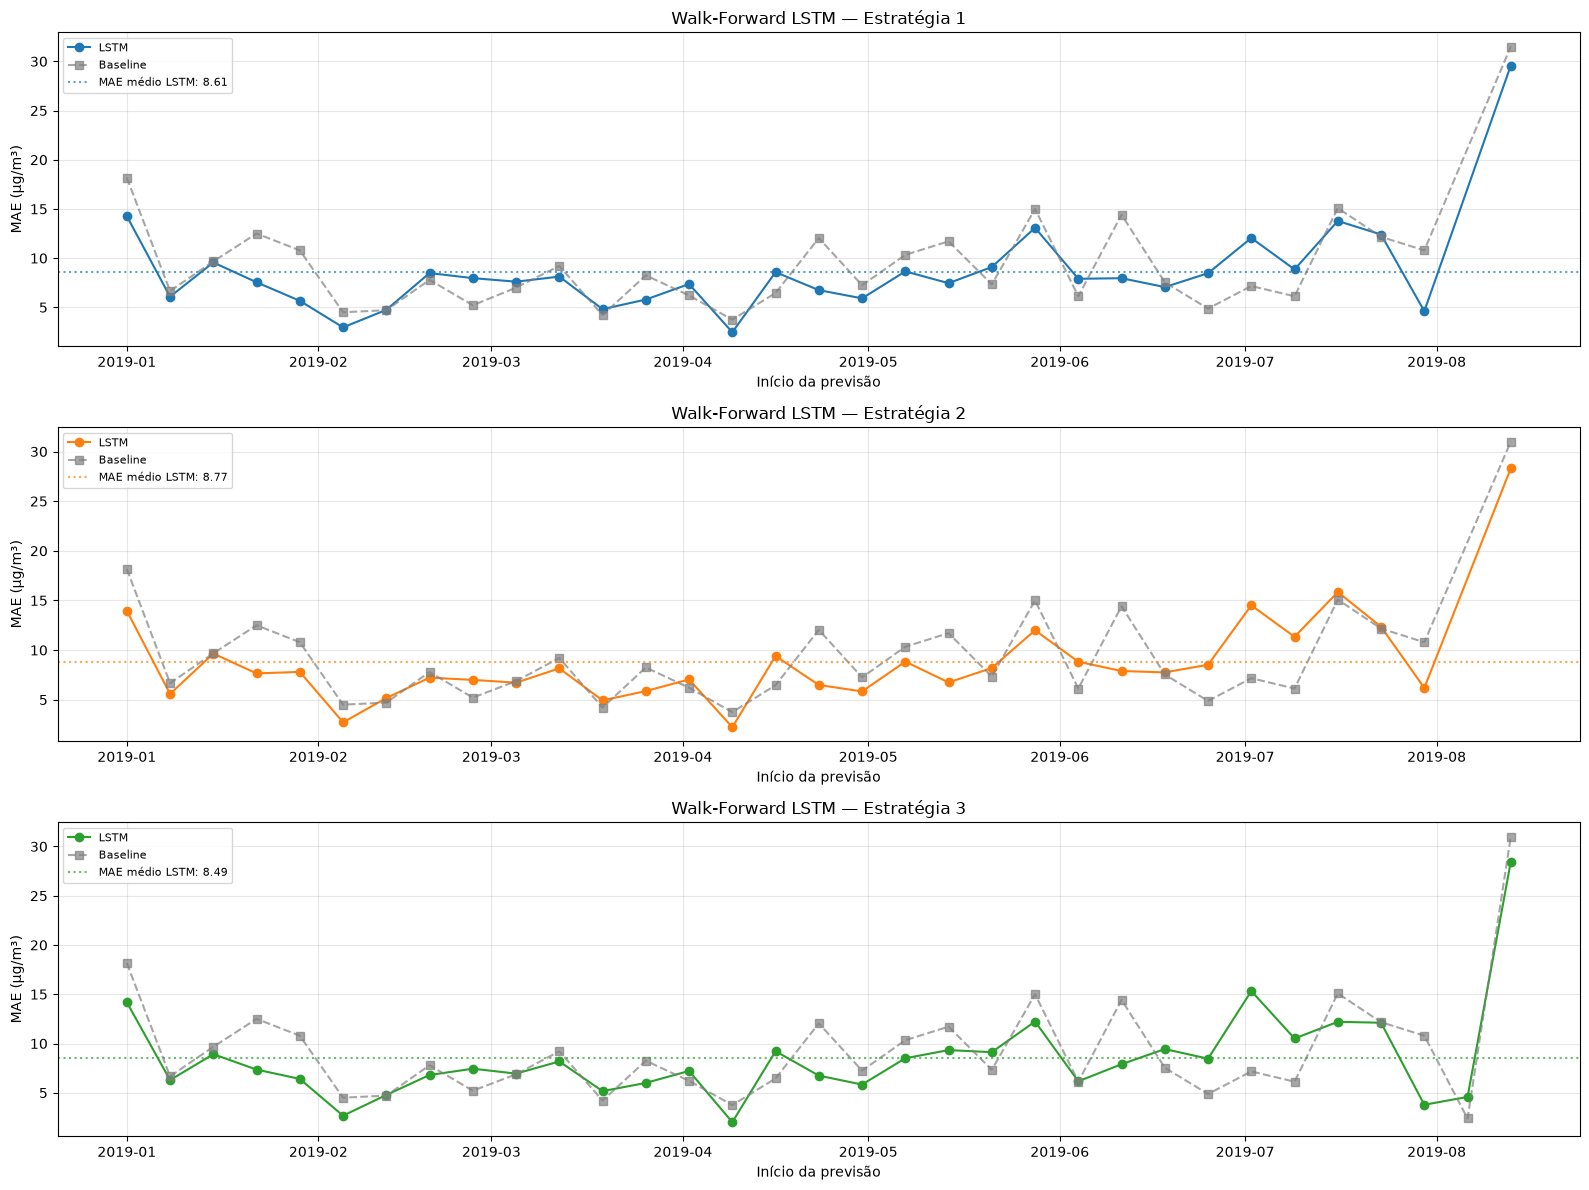

In [110]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

for ax, df_wf, nome, cor in zip(
    axes,
    [df_wf_01, df_wf_02, df_wf_03],
    ["Estratégia 1", "Estratégia 2", "Estratégia 3"],
    ["tab:blue", "tab:orange", "tab:green"]
):
    ax.plot(
        df_wf["inicio_previsao"],
        df_wf["mae_lstm"],
        marker="o", label="LSTM", color=cor
    )
    ax.plot(
        df_wf["inicio_previsao"],
        df_wf["mae_baseline"],
        marker="s", linestyle="--", label="Baseline", color="gray", alpha=0.7
    )
    ax.axhline(
        df_wf["mae_lstm"].mean(),
        color=cor, linestyle=":", alpha=0.7,
        label=f"MAE médio LSTM: {df_wf['mae_lstm'].mean():.2f}"
    )
    ax.set_title(f"Walk-Forward LSTM — {nome}")
    ax.set_ylabel("MAE (µg/m³)")
    ax.set_xlabel("Início da previsão")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [111]:
def metricas_walk_forward(df_wf, nome_estrategia):
    mae  = df_wf["mae_lstm"].mean()
    rmse = df_wf["rmse_lstm"].mean()
    return {
        "estrategia": nome_estrategia,
        "modelo": "LSTM Walk-Forward",
        "MAE":  mae,
        "RMSE": rmse,
        "melhora_mae_%": df_wf["melhora_mae_%"].mean()
    }

comparacao_walk_forward = pd.DataFrame([
    metricas_walk_forward(df_wf_01, "Estratégia 1"),
    metricas_walk_forward(df_wf_02, "Estratégia 2"),
    metricas_walk_forward(df_wf_03, "Estratégia 3"),
])

comparacao_walk_forward.sort_values("RMSE")

,estrategia,modelo,MAE,RMSE,melhora_mae_%
2,Estratégia 3,LSTM Walk-Forward,8.492259,10.323316,-0.425709
0,Estratégia 1,LSTM Walk-Forward,8.614261,10.461575,3.145950
1,Estratégia 2,LSTM Walk-Forward,8.771976,10.622816,0.863812


## Experimento 8 adaptar para multi-step do horizonte

In [112]:
def criar_janelas_multistep(data, lookback, horizon):
    X, y = [], []
    n = len(data)
    for i in range(n - lookback - horizon + 1):
        janela = data[i : i + lookback + horizon]
        if np.isnan(janela).any():
            continue
        X.append(data[i : i + lookback])
        y.append(data[i + lookback : i + lookback + horizon, 0])  # PM2.5 das próximas 24h
    return np.array(X), np.array(y)

In [113]:

def prep_dados_lstm_multistep(train, val, test, features, lookback, horizon):
    train = train.copy()
    val   = val.copy()
    test  = test.copy()

    for df in [train, val, test]:
        df[features] = df[features].ffill()

    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train[features])
    val_scaled   = scaler.transform(val[features])
    test_scaled  = scaler.transform(test[features])

    X_train, y_train = criar_janelas_multistep(train_scaled, lookback, horizon)
    X_val,   y_val   = criar_janelas_multistep(val_scaled,   lookback, horizon)
    X_test,  y_test  = criar_janelas_multistep(test_scaled,  lookback, horizon)

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler

In [114]:
X_train_ms01, y_train_ms01, X_val_ms01, y_val_ms01, X_test_ms01, y_test_ms01, scaler_ms01 = prep_dados_lstm_multistep(
    train_01, val_01, test_01, FEATURES, LOOKBACK, HORIZON
)
X_train_ms02, y_train_ms02, X_val_ms02, y_val_ms02, X_test_ms02, y_test_ms02, scaler_ms02 = prep_dados_lstm_multistep(
    train_02, val_02, test_02, FEATURES, LOOKBACK, HORIZON
)
X_train_ms03, y_train_ms03, X_val_ms03, y_val_ms03, X_test_ms03, y_test_ms03, scaler_ms03 = prep_dados_lstm_multistep(
    train_03, val_03, test_03, FEATURES, LOOKBACK, HORIZON
)


In [115]:
print(f"X_train shape: {X_train_ms01.shape}")
print(f"y_train shape: {y_train_ms01.shape}")  # esperado: (amostras, 24)

X_train shape: (16057, 24, 5)
y_train shape: (16057, 24)


In [116]:
def build_lstm_multistep(input_shape, horizon, units=64, n_layers=1,
                          dropout=0.0, recurrent_dropout=0.0, learning_rate=0.001):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        x = LSTM(
            units,
            activation="tanh",
            return_sequences=return_seq,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout
        )(x)
    outputs = Dense(horizon, activation="linear")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mae")
    return model

In [119]:
def avaliar_modelo_lstm_multistep(y_true_scaled, y_pred_scaled, scaler, n_features):
    """
    y_true e y_pred têm shape (amostras, 24)
    Desnormaliza e calcula métricas sobre todos os pontos — R² global
    """
    def desnormalizar(values_2d):
        n_samples, n_steps = values_2d.shape
        result = []
        for i in range(n_samples):
            dummy = np.zeros((n_steps, n_features))
            dummy[:, 0] = values_2d[i]
            result.append(scaler.inverse_transform(dummy)[:, 0])
        return np.array(result)

    y_true = desnormalizar(y_true_scaled).flatten()
    y_pred = desnormalizar(y_pred_scaled).flatten()
    y_pred = np.clip(y_pred, 0, None)

    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred)
    }

In [120]:
model_ms_b01, _ = treinar_lstm(
    X_train_ms01, y_train_ms01, X_val_ms01, y_val_ms01,
    build_lstm_multistep((LOOKBACK, len(FEATURES)), HORIZON)
)
model_ms_b02, _ = treinar_lstm(
    X_train_ms02, y_train_ms02, X_val_ms02, y_val_ms02,
    build_lstm_multistep((LOOKBACK, len(FEATURES)), HORIZON)
)
model_ms_b03, _ = treinar_lstm(
    X_train_ms03, y_train_ms03, X_val_ms03, y_val_ms03,
    build_lstm_multistep((LOOKBACK, len(FEATURES)), HORIZON)
)

In [121]:
res_ms_b_val_01 = avaliar_modelo_lstm_multistep(y_val_ms01, model_ms_b01.predict(X_val_ms01, verbose=0), scaler_ms01, len(FEATURES))
res_ms_b_val_02 = avaliar_modelo_lstm_multistep(y_val_ms02, model_ms_b02.predict(X_val_ms02, verbose=0), scaler_ms02, len(FEATURES))
res_ms_b_val_03 = avaliar_modelo_lstm_multistep(y_val_ms03, model_ms_b03.predict(X_val_ms03, verbose=0), scaler_ms03, len(FEATURES))

In [122]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "LSTM Multi-Step Baseline", **res_ms_b_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Multi-Step Baseline", **res_ms_b_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Multi-Step Baseline", **res_ms_b_val_03},
])

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,LSTM Multi-Step Baseline,6.997756,10.062851,0.381462
1,Estratégia 2,LSTM Multi-Step Baseline,7.012776,9.928476,0.397890
2,Estratégia 3,LSTM Multi-Step Baseline,6.897882,9.799490,0.402072


In [123]:
comparacao_multistep = pd.DataFrame([
    # Single-step baseline
    {"estrategia": "Estratégia 1", "modelo": "LSTM Single-Step Baseline", **res_b_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Single-Step Baseline", **res_b_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Single-Step Baseline", **res_b_val_03},

    # Single-step tuned
    {"estrategia": "Estratégia 1", "modelo": "LSTM Single-Step Tuned", **res_tuned_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Single-Step Tuned", **res_tuned_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Single-Step Tuned", **res_tuned_val_03},

    # Multi-step baseline
    {"estrategia": "Estratégia 1", "modelo": "LSTM Multi-Step Baseline", **res_ms_b_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM Multi-Step Baseline", **res_ms_b_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM Multi-Step Baseline", **res_ms_b_val_03},
])

comparacao_multistep.sort_values("RMSE")

,estrategia,modelo,MAE,RMSE,R2
8,Estratégia 3,LSTM Multi-Step Baseline,6.897882,9.799490,0.402072
7,Estratégia 2,LSTM Multi-Step Baseline,7.012776,9.928476,0.397890
6,Estratégia 1,LSTM Multi-Step Baseline,6.997756,10.062851,0.381462
5,Estratégia 3,LSTM Single-Step Tuned,7.350104,10.248173,0.345522
1,Estratégia 2,LSTM Single-Step Baseline,7.666005,10.538977,0.321014
2,Estratégia 3,LSTM Single-Step Baseline,7.512632,10.540513,0.307650
4,Estratégia 2,LSTM Single-Step Tuned,7.609666,10.557437,0.318633
0,Estratégia 1,LSTM Single-Step Baseline,7.563833,10.571716,0.316767
3,Estratégia 1,LSTM Single-Step Tuned,7.689672,10.628958,0.309348


### o Multi-Step Baseline já supera o Single-Step Tuned em todas as estratégias, sem nenhum tuning ainda

In [124]:
def build_model_tuner_multistep(hp):
    units              = hp.Choice("units", [32, 64, 128, 256])
    n_layers           = hp.Int("n_layers", min_value=1, max_value=3)
    dropout            = hp.Float("dropout", min_value=0.0, max_value=0.4, step=0.1)
    recurrent_dropout  = hp.Float("recurrent_dropout", min_value=0.0, max_value=0.2, step=0.1)
    learning_rate      = hp.Choice("learning_rate", [1e-4, 5e-4, 1e-3, 5e-3])

    inputs = tf.keras.Input(shape=(LOOKBACK, len(FEATURES)))
    x = inputs

    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        x = LSTM(
            units,
            activation="tanh",
            return_sequences=return_seq,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout
        )(x)

    outputs = Dense(HORIZON, activation="linear")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mae"
    )
    return model

In [125]:
tuner_ms = kt.BayesianOptimization(
    build_model_tuner_multistep,
    objective="val_loss",
    max_trials=50,
    num_initial_points=10,
    overwrite=True,
    directory="keras_tuner_lstm_ms",
    project_name="pm25_lstm_multistep"
)

early_stop_ms = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=0
)

print("Iniciando busca Multi-Step — Estratégia 3...")

tuner_ms.search(
    X_train_ms03, y_train_ms03,
    validation_data=(X_val_ms03, y_val_ms03),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop_ms],
    verbose=0
)

print("\nBusca concluída.")

Iniciando busca Multi-Step — Estratégia 3...


/opt/micromamba/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/micromamba/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)



Busca concluída.


In [126]:
best_hps_ms = tuner_ms.get_best_hyperparameters(num_trials=1)[0]

print("Melhor configuração Multi-Step:")
print(f"  units:             {best_hps_ms.get('units')}")
print(f"  n_layers:          {best_hps_ms.get('n_layers')}")
print(f"  dropout:           {best_hps_ms.get('dropout')}")
print(f"  recurrent_dropout: {best_hps_ms.get('recurrent_dropout')}")
print(f"  learning_rate:     {best_hps_ms.get('learning_rate')}")

Melhor configuração Multi-Step:
  units:             256
  n_layers:          1
  dropout:           0.2
  recurrent_dropout: 0.2
  learning_rate:     0.0005


In [127]:
def treinar_modelo_tuned_ms(X_train, y_train, X_val, y_val, best_hps):
    model = build_model_tuner_multistep(best_hps)
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0
    )
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )
    return model

In [129]:
model_ms_tuned_01 = treinar_modelo_tuned_ms(X_train_ms01, y_train_ms01, X_val_ms01, y_val_ms01, best_hps_ms)
model_ms_tuned_02 = treinar_modelo_tuned_ms(X_train_ms02, y_train_ms02, X_val_ms02, y_val_ms02, best_hps_ms)
model_ms_tuned_03 = treinar_modelo_tuned_ms(X_train_ms03, y_train_ms03, X_val_ms03, y_val_ms03, best_hps_ms)

In [130]:
# Validação
res_ms_tuned_val_01 = avaliar_modelo_lstm_multistep(y_val_ms01, model_ms_tuned_01.predict(X_val_ms01, verbose=0), scaler_ms01, len(FEATURES))
res_ms_tuned_val_02 = avaliar_modelo_lstm_multistep(y_val_ms02, model_ms_tuned_02.predict(X_val_ms02, verbose=0), scaler_ms02, len(FEATURES))
res_ms_tuned_val_03 = avaliar_modelo_lstm_multistep(y_val_ms03, model_ms_tuned_03.predict(X_val_ms03, verbose=0), scaler_ms03, len(FEATURES))

In [131]:
# Teste
res_ms_tuned_test_01 = avaliar_modelo_lstm_multistep(y_test_ms01, model_ms_tuned_01.predict(X_test_ms01, verbose=0), scaler_ms01, len(FEATURES))
res_ms_tuned_test_02 = avaliar_modelo_lstm_multistep(y_test_ms02, model_ms_tuned_02.predict(X_test_ms02, verbose=0), scaler_ms02, len(FEATURES))
res_ms_tuned_test_03 = avaliar_modelo_lstm_multistep(y_test_ms03, model_ms_tuned_03.predict(X_test_ms03, verbose=0), scaler_ms03, len(FEATURES))

In [132]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "LSTM MS Tuned", "split": "Validação", **res_ms_tuned_val_01},
    {"estrategia": "Estratégia 1", "modelo": "LSTM MS Tuned", "split": "Teste",     **res_ms_tuned_test_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM MS Tuned", "split": "Validação", **res_ms_tuned_val_02},
    {"estrategia": "Estratégia 2", "modelo": "LSTM MS Tuned", "split": "Teste",     **res_ms_tuned_test_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM MS Tuned", "split": "Validação", **res_ms_tuned_val_03},
    {"estrategia": "Estratégia 3", "modelo": "LSTM MS Tuned", "split": "Teste",     **res_ms_tuned_test_03},
])

,estrategia,modelo,split,MAE,RMSE,R2
0,Estratégia 1,LSTM MS Tuned,Validação,6.990852,9.912957,0.399752
1,Estratégia 1,LSTM MS Tuned,Teste,7.128189,10.241906,0.391960
2,Estratégia 2,LSTM MS Tuned,Validação,6.985427,9.943690,0.396043
3,Estratégia 2,LSTM MS Tuned,Teste,7.127262,10.293110,0.385563
4,Estratégia 3,LSTM MS Tuned,Validação,6.837688,9.714525,0.412395
5,Estratégia 3,LSTM MS Tuned,Teste,6.945730,9.998351,0.395923


In [133]:
def walk_forward_lstm_ms(
    df_total,
    train_size,
    features,
    horizon=24,
    step=24*7,
    epochs=50,
    batch_size=64,
    units=256,
    n_layers=1,
    dropout=0.2,
    recurrent_dropout=0.2,
    learning_rate=0.0005
):
    resultados = []
    n_total = len(df_total)
    n_test  = n_total - train_size
    
    all_y_true = []
    all_y_pred = []

    for start in range(0, n_test - horizon + 1, step):
        print(f"Janela {start} → {start + horizon} de {n_test}...")

        idx_fim_treino = train_size + start
        df_train_i = df_total.iloc[:idx_fim_treino].copy()
        df_test_i  = df_total.iloc[idx_fim_treino:idx_fim_treino + horizon].copy()

        df_train_i[features] = df_train_i[features].ffill()
        df_test_i[features]  = df_test_i[features].ffill()

        scaler_i     = StandardScaler()
        train_scaled = scaler_i.fit_transform(df_train_i[features])
        test_scaled  = scaler_i.transform(df_test_i[features])

        X_tr, y_tr = criar_janelas_multistep(train_scaled, LOOKBACK, horizon)

        if len(X_tr) == 0:
            continue

        model_i = build_lstm_multistep(
            input_shape=(LOOKBACK, len(features)),
            horizon=horizon,
            units=units,
            n_layers=n_layers,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            learning_rate=learning_rate
        )

        val_size = max(int(len(X_tr) * 0.1), LOOKBACK)
        early_stop = EarlyStopping(monitor="val_loss", patience=5,
                                   restore_best_weights=True, verbose=0)

        model_i.fit(
            X_tr[:-val_size], y_tr[:-val_size],
            validation_data=(X_tr[-val_size:], y_tr[-val_size:]),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0
        )

        # Previsão das próximas 24h
        contexto   = train_scaled[-LOOKBACK:]
        X_pred     = contexto.reshape(1, LOOKBACK, len(features))
        y_pred_scaled = model_i.predict(X_pred, verbose=0)[0]  # shape (24,)

        # Desnormalizar previsão
        dummy_pred = np.zeros((horizon, len(features)))
        dummy_pred[:, 0] = y_pred_scaled
        y_pred_real = scaler_i.inverse_transform(dummy_pred)[:, 0]
        y_pred_real = np.clip(y_pred_real, 0, None)

        # Target real
        y_true_vals = df_test_i["PM2.5"].values
        mask        = ~np.isnan(y_true_vals)

        if mask.sum() == 0:
            continue

        # Acumular para R² global
        all_y_true.extend(y_true_vals[mask].tolist())
        all_y_pred.extend(y_pred_real[mask].tolist())

        # Baseline
        y_baseline = df_total["PM2.5"].iloc[
            idx_fim_treino - horizon:idx_fim_treino
        ].values
        mask_base = ~np.isnan(y_baseline)

        mae_model  = mean_absolute_error(y_true_vals[mask], y_pred_real[mask])
        rmse_model = np.sqrt(mean_squared_error(y_true_vals[mask], y_pred_real[mask]))
        r2_model   = r2_score(y_true_vals[mask], y_pred_real[mask]) \
                     if mask.sum() > 1 else np.nan

        mae_baseline = mean_absolute_error(
            y_true_vals[mask & mask_base],
            y_baseline[mask & mask_base]
        ) if (mask & mask_base).sum() > 0 else np.nan

        melhora_mae = 100 * (mae_baseline - mae_model) / mae_baseline \
                      if mae_baseline and mae_baseline != 0 else np.nan

        resultados.append({
            "start":           start,
            "inicio_previsao": df_test_i["time"].iloc[0],
            "fim_previsao":    df_test_i["time"].iloc[-1],
            "mes":             str(pd.Period(df_test_i["time"].iloc[0], "M")),
            "n_obs":           mask.sum(),
            "mae_lstm":        mae_model,
            "rmse_lstm":       rmse_model,
            "r2_lstm":         r2_model,
            "mae_baseline":    mae_baseline,
            "melhora_mae_%":   melhora_mae
        })

        tf.keras.backend.clear_session()

    # R² global — calculado sobre todas as janelas concatenadas
    r2_global = r2_score(all_y_true, all_y_pred)
    print(f"\nR² global: {r2_global:.4f}")

    df_result = pd.DataFrame(resultados)
    df_result.attrs["r2_global"] = r2_global

    return df_result, r2_global

In [135]:
df_total_ms01 = pd.concat([train_01, test_01]).reset_index(drop=True)
df_total_ms02 = pd.concat([train_02, test_02]).reset_index(drop=True)
df_total_ms03 = pd.concat([train_03, test_03]).reset_index(drop=True)

In [136]:
print("Walk-Forward Multi-Step — Estratégia 1...")
df_wf_ms01, r2_global_ms01 = walk_forward_lstm_ms(
    df_total_ms01, len(train_01), FEATURES
)

print("\nWalk-Forward Multi-Step — Estratégia 2...")
df_wf_ms02, r2_global_ms02 = walk_forward_lstm_ms(
    df_total_ms02, len(train_02), FEATURES
)

print("\nWalk-Forward Multi-Step — Estratégia 3...")
df_wf_ms03, r2_global_ms03 = walk_forward_lstm_ms(
    df_total_ms03, len(train_03), FEATURES
)

Walk-Forward Multi-Step — Estratégia 1...
Janela 0 → 24 de 5499...
Janela 168 → 192 de 5499...
Janela 336 → 360 de 5499...
Janela 504 → 528 de 5499...
Janela 672 → 696 de 5499...
Janela 840 → 864 de 5499...
Janela 1008 → 1032 de 5499...
Janela 1176 → 1200 de 5499...
Janela 1344 → 1368 de 5499...
Janela 1512 → 1536 de 5499...
Janela 1680 → 1704 de 5499...
Janela 1848 → 1872 de 5499...
Janela 2016 → 2040 de 5499...
Janela 2184 → 2208 de 5499...
Janela 2352 → 2376 de 5499...
Janela 2520 → 2544 de 5499...
Janela 2688 → 2712 de 5499...
Janela 2856 → 2880 de 5499...
Janela 3024 → 3048 de 5499...
Janela 3192 → 3216 de 5499...
Janela 3360 → 3384 de 5499...
Janela 3528 → 3552 de 5499...
Janela 3696 → 3720 de 5499...
Janela 3864 → 3888 de 5499...
Janela 4032 → 4056 de 5499...
Janela 4200 → 4224 de 5499...
Janela 4368 → 4392 de 5499...
Janela 4536 → 4560 de 5499...
Janela 4704 → 4728 de 5499...
Janela 4872 → 4896 de 5499...
Janela 5040 → 5064 de 5499...
Janela 5208 → 5232 de 5499...
Janela 5376 →

In [137]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "mae_medio": df_wf_ms01["mae_lstm"].mean(),
     "rmse_medio": df_wf_ms01["rmse_lstm"].mean(), "r2_global": r2_global_ms01,
     "melhora_mae_%": df_wf_ms01["melhora_mae_%"].mean()},
    {"estrategia": "Estratégia 2", "mae_medio": df_wf_ms02["mae_lstm"].mean(),
     "rmse_medio": df_wf_ms02["rmse_lstm"].mean(), "r2_global": r2_global_ms02,
     "melhora_mae_%": df_wf_ms02["melhora_mae_%"].mean()},
    {"estrategia": "Estratégia 3", "mae_medio": df_wf_ms03["mae_lstm"].mean(),
     "rmse_medio": df_wf_ms03["rmse_lstm"].mean(), "r2_global": r2_global_ms03,
     "melhora_mae_%": df_wf_ms03["melhora_mae_%"].mean()},
]).round(3)

,estrategia,mae_medio,rmse_medio,r2_global,melhora_mae_%
0,Estratégia 1,7.398,9.453,0.202,19.482
1,Estratégia 2,7.417,9.480,0.211,18.017
2,Estratégia 3,7.395,9.423,0.179,14.040


In [138]:
comparacao_final_lstm = pd.DataFrame([
    # Single-Step Baseline — Validação
    {"estrategia": "Estratégia 1", "modelo": "LSTM SS Baseline",    "split": "Validação", **res_b_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM SS Baseline",    "split": "Validação", **res_b_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM SS Baseline",    "split": "Validação", **res_b_val_03},

    # Single-Step + Cíclicas — Validação
    {"estrategia": "Estratégia 1", "modelo": "LSTM SS + Cíclicas",  "split": "Validação", **res_fe_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM SS + Cíclicas",  "split": "Validação", **res_fe_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM SS + Cíclicas",  "split": "Validação", **res_fe_val_03},

    # Single-Step + Fourier — Validação
    {"estrategia": "Estratégia 1", "modelo": "LSTM SS + Fourier",   "split": "Validação", **res_f_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM SS + Fourier",   "split": "Validação", **res_f_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM SS + Fourier",   "split": "Validação", **res_f_val_03},

    # Single-Step + is_winter — Validação
    {"estrategia": "Estratégia 1", "modelo": "LSTM SS + is_winter", "split": "Validação", **res_iw_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM SS + is_winter", "split": "Validação", **res_iw_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM SS + is_winter", "split": "Validação", **res_iw_val_03},

    # Single-Step Tuned — Validação e Teste
    {"estrategia": "Estratégia 1", "modelo": "LSTM SS Tuned", "split": "Validação", **res_tuned_val_01},
    {"estrategia": "Estratégia 1", "modelo": "LSTM SS Tuned", "split": "Teste",     **res_tuned_test_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM SS Tuned", "split": "Validação", **res_tuned_val_02},
    {"estrategia": "Estratégia 2", "modelo": "LSTM SS Tuned", "split": "Teste",     **res_tuned_test_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM SS Tuned", "split": "Validação", **res_tuned_val_03},
    {"estrategia": "Estratégia 3", "modelo": "LSTM SS Tuned", "split": "Teste",     **res_tuned_test_03},

    # Multi-Step Baseline — Validação
    {"estrategia": "Estratégia 1", "modelo": "LSTM MS Baseline", "split": "Validação", **res_ms_b_val_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM MS Baseline", "split": "Validação", **res_ms_b_val_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM MS Baseline", "split": "Validação", **res_ms_b_val_03},

    # Multi-Step Tuned — Validação e Teste
    {"estrategia": "Estratégia 1", "modelo": "LSTM MS Tuned", "split": "Validação", **res_ms_tuned_val_01},
    {"estrategia": "Estratégia 1", "modelo": "LSTM MS Tuned", "split": "Teste",     **res_ms_tuned_test_01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM MS Tuned", "split": "Validação", **res_ms_tuned_val_02},
    {"estrategia": "Estratégia 2", "modelo": "LSTM MS Tuned", "split": "Teste",     **res_ms_tuned_test_02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM MS Tuned", "split": "Validação", **res_ms_tuned_val_03},
    {"estrategia": "Estratégia 3", "modelo": "LSTM MS Tuned", "split": "Teste",     **res_ms_tuned_test_03},

    # Walk-Forward Single-Step — Teste
    {"estrategia": "Estratégia 1", "modelo": "LSTM SS Walk-Forward", "split": "Teste",
     "MAE": df_wf_01["mae_lstm"].mean(), "RMSE": df_wf_01["rmse_lstm"].mean(), "R2": None},
    {"estrategia": "Estratégia 2", "modelo": "LSTM SS Walk-Forward", "split": "Teste",
     "MAE": df_wf_02["mae_lstm"].mean(), "RMSE": df_wf_02["rmse_lstm"].mean(), "R2": None},
    {"estrategia": "Estratégia 3", "modelo": "LSTM SS Walk-Forward", "split": "Teste",
     "MAE": df_wf_03["mae_lstm"].mean(), "RMSE": df_wf_03["rmse_lstm"].mean(), "R2": None},

    # Walk-Forward Multi-Step — Teste
    {"estrategia": "Estratégia 1", "modelo": "LSTM MS Walk-Forward", "split": "Teste",
     "MAE": df_wf_ms01["mae_lstm"].mean(), "RMSE": df_wf_ms01["rmse_lstm"].mean(), "R2": r2_global_ms01},
    {"estrategia": "Estratégia 2", "modelo": "LSTM MS Walk-Forward", "split": "Teste",
     "MAE": df_wf_ms02["mae_lstm"].mean(), "RMSE": df_wf_ms02["rmse_lstm"].mean(), "R2": r2_global_ms02},
    {"estrategia": "Estratégia 3", "modelo": "LSTM MS Walk-Forward", "split": "Teste",
     "MAE": df_wf_ms03["mae_lstm"].mean(), "RMSE": df_wf_ms03["rmse_lstm"].mean(), "R2": r2_global_ms03},
])

comparacao_final_lstm.sort_values("RMSE")

,estrategia,modelo,split,MAE,RMSE,R2
32,Estratégia 3,LSTM MS Walk-Forward,Teste,7.395105,9.423128,0.178572
30,Estratégia 1,LSTM MS Walk-Forward,Teste,7.398348,9.453485,0.201602
31,Estratégia 2,LSTM MS Walk-Forward,Teste,7.417488,9.479511,0.210913
25,Estratégia 3,LSTM MS Tuned,Validação,6.837688,9.714525,0.412395
20,Estratégia 3,LSTM MS Baseline,Validação,6.897882,9.799490,0.402072
21,Estratégia 1,LSTM MS Tuned,Validação,6.990852,9.912957,0.399752
19,Estratégia 2,LSTM MS Baseline,Validação,7.012776,9.928476,0.397890
23,Estratégia 2,LSTM MS Tuned,Validação,6.985427,9.943690,0.396043
26,Estratégia 3,LSTM MS Tuned,Teste,6.945730,9.998351,0.395923
18,Estratégia 1,LSTM MS Baseline,Validação,6.997756,10.062851,0.381462
